In [1]:
import csv
import os
import pandas as pd
import collections
import ast
import time
import collections
import json
import sqlite3
import xxhash
import numpy as np
import pickle 
import random
import glob
from io import StringIO
from pathlib import Path
from openai import OpenAI, AsyncOpenAI
import openai
print(openai.__version__)
os.environ["OPENAI_API_KEY"] = ""

openai.api_key = os.getenv("OPENAI_API_KEY")

client = OpenAI(
    api_key=os.getenv("OPENAI_API_KEY"),
)

1.90.0


In [2]:
import sys
sys.path.append('./..')
from prompts.all_prompts import *
from order_by.sorting import *
from order_by.utils import *

In [3]:
import matplotlib.pyplot as plt

In [5]:
def sortedness(gold_list, sorted_data):
    kendalltau = kendalltau_distance(gold_list[:], sorted_data[:])
    return kendalltau

def store_metadata(d, sorted_data, kendalltau, api_calls, tokens, memory_size = 0):
    if memory_size == 0:
        d['sorted_data'] = sorted_data
        d['kendalltau'] = kendalltau
        d['api_calls'] = api_calls
        d['tokens'] = tokens
    else:
        d[memory_size] = {}
        d[memory_size]['sorted_data'] = sorted_data
        d[memory_size]['kendalltau'] = kendalltau
        d[memory_size]['api_calls'] = api_calls
        d[memory_size]['tokens'] = tokens
        
    
def tokens2price(model, in_tokens, out_tokens):
    """
    Calculate the API cost given the model and number of input/output tokens.

    Pricing (as of Sep 2025):
    - gpt-4o:       $2.50 per 1M input tokens, $10.00 per 1M output tokens
    - gpt-4o-mini:  $0.150 per 1M input tokens, $0.600 per 1M output tokens
    """
    if model == 'gpt-4o':
        input_rate = 2.50 / 1_000_000
        output_rate = 10.00 / 1_000_000
    elif model == 'gpt-4o-mini':
        input_rate = 0.150 / 1_000_000
        output_rate = 0.600 / 1_000_000
    else:
        raise ValueError(f"Unknown model: {model}")

    total_cost = in_tokens * input_rate + out_tokens * output_rate
    return round(total_cost, 6) 
        
        
    
async def experiment(dataname, sort_by_columns, column_to_compare, log_filename, pointwise_prompt_template,\
               external_pointwise_prompt_template, external_comparison_prompt_template,\
               pairwise_comparison_prompt_template, tolerance = 0.01, out_t = float):
    random.seed(0)
    
    fname = f"{dataname}.csv"
    file_path = f"../data/{fname}"
    data = pd.read_csv(file_path)

    sorted_df = data.sort_values(by=sort_by_columns, ascending=[True, True])
    
    gold_list = sorted_df[column_to_compare].tolist()
    print(gold_list[:10])
    shuffled_list = random.sample(gold_list, len(gold_list)) # shuffle the sorted list
    print(shuffled_list)
    results = {}
    for modelname in ["gpt-4o-mini", "gpt-4o"]:
        results[modelname] = {'pointwise_sort':{}, 'quick_sort':{}, 'quick_sort_3':{}, 'heap_sort':{},\
                              'external_pointwise_sort':{}, 'external_bubble_sort':{},\
                              'external_merge_sort':{}, 'hybrid_sort_3':{}, 'quick_sort_5':{}}
        memory_sizes = [8, 16]
        if modelname == 'gpt-4o-mini':
            memory_sizes = [4, 8]
        print(modelname)
        
        sorted_data, num_api_calls, in_tokens, out_tokens, confidences = await pointwise_sort(shuffled_list[:], client, pointwise_prompt_template, modelname, out_t)
        kendalltau = sortedness(gold_list, sorted_data)
        print("pointwise_sort")
        print(f"kendalltau score: {kendalltau}, tokens: {in_tokens+out_tokens}, price: {tokens2price(modelname, in_tokens, out_tokens)}.\n {confidences}")

        sorted_data, num_api_calls, in_tokens, out_tokens = await quick_sort(shuffled_list[:], client, pairwise_comparison_prompt_template, modelname, False, 1)
        kendalltau = sortedness(gold_list, sorted_data)
        print("quick_sort")
        print(f"kendalltau score: {kendalltau}, tokens: {in_tokens+out_tokens}, price: {tokens2price(modelname, in_tokens, out_tokens)}.\n")

        votes = 3
        sorted_data, num_api_calls, in_tokens, out_tokens = await quick_sort(shuffled_list[:], client, pairwise_comparison_prompt_template, modelname, False, votes)
        kendalltau = sortedness(gold_list, sorted_data)
        print(f"quick_sort with vote={votes}")
        print(f"kendalltau score: {kendalltau}, tokens: {in_tokens+out_tokens}, price: {tokens2price(modelname, in_tokens, out_tokens)}.\n")


        sorted_data, num_api_calls, in_tokens, out_tokens, confidences = await external_pointwise_sort(shuffled_list[:], external_values, client, external_pointwise_prompt_template, modelname, out_t, tolerance)
        kendalltau = sortedness(gold_list, sorted_data)
        print(f"kendalltau score: {kendalltau}, tokens: {in_tokens+out_tokens}, price: {tokens2price(modelname, in_tokens, out_tokens)}.\n {confidences}\n")

    
        for m in memory_sizes:
            sorted_data, num_api_calls, in_tokens, out_tokens = await external_bubble_sort(shuffled_list[:], external_comparisons, m, client, external_comparison_prompt_template, modelname)
            print(f"external_bubble_sort sorted data length {len(sorted_data)}")
            kendalltau = sortedness(gold_list, sorted_data)
            print(f"external_bubble_sort {m}")
            print(f"kendalltau score: {kendalltau}, tokens: {in_tokens+out_tokens}, price: {tokens2price(modelname, in_tokens, out_tokens)}\n")


            sorted_data, num_api_calls, in_tokens, out_tokens = await external_merge_sort(shuffled_list[:], external_comparisons, m, client, external_comparison_prompt_template, modelname)
            print(f"external_merge_sort sorted data length {len(sorted_data)}")
            kendalltau = sortedness(gold_list, sorted_data)
            print(f"external_merge_sort {m}")
            print(f"kendalltau score: {kendalltau}, tokens: {in_tokens+out_tokens}, price: {tokens2price(modelname, in_tokens, out_tokens)}.\n")


In [5]:
dataname = "nba_heights_200"
column_to_sort = "full_name"
log_filename = "./logs/nba_heights.json"
await experiment(
         dataname,
        ["h_meters", "full_name"],
        "full_name",
        log_filename,
        nba_pointwise_prompt_template,
        nba_external_pointwise_prompt_template, 
        nba_external_comparison_prompt_template,
        nba_pairwise_comparison_prompt_template,
        0.01,
        float
    )

['Paul Millsap', 'Jeff Green', 'Kevin Love', 'Luc Mbah a Moute', 'Luke Walton', 'Mike Miller', 'Nicolas Batum', 'Othello Hunter', 'Reggie Evans', 'Renaldo Balkman']
['Nick Collison', 'Spencer Hawes', 'Solomon Jones', 'Rudy Gay', 'Sean May', 'Jarron Collins', 'Donte Greene', 'Sean Marks', 'Brandan Wright', 'Dan Gadzuric', 'Lamar Odom', 'Tim Duncan', 'Louis Amundson', 'Jared Jeffries', 'Darius Songaila', 'Zach Randolph', 'Pau Gasol', 'Antoine Walker', 'Brendan Haywood', 'Rob Kurz', 'Kevin Garnett', 'Andrea Bargnani', 'Darrell Arthur', 'Chris Wilcox', 'Antonio McDyess', 'Al Harrington', 'Etan Thomas', 'Charlie Villanueva', 'Mehmet Okur', 'Mikki Moore', 'Kendrick Perkins', 'Tim Thomas', 'Danilo Gallinari', 'Andrew Bynum', 'DeSagana Diop', 'Kenyon Martin', 'Marcin Gortat', 'Kyrylo Fesenko', 'Vladimir Radmanovic', "Jermaine O'Neal", 'Alexis Ajinca', 'Trevor Ariza', 'Marc Gasol', 'Luc Mbah a Moute', 'Antawn Jamison', 'Ryan Anderson', 'Paul Millsap', 'Hilton Armstrong', 'Fabricio Oberto', 'Mik

Fitted parameters:
A = 0.0530
B = 0.7996
x0 = 0.0000


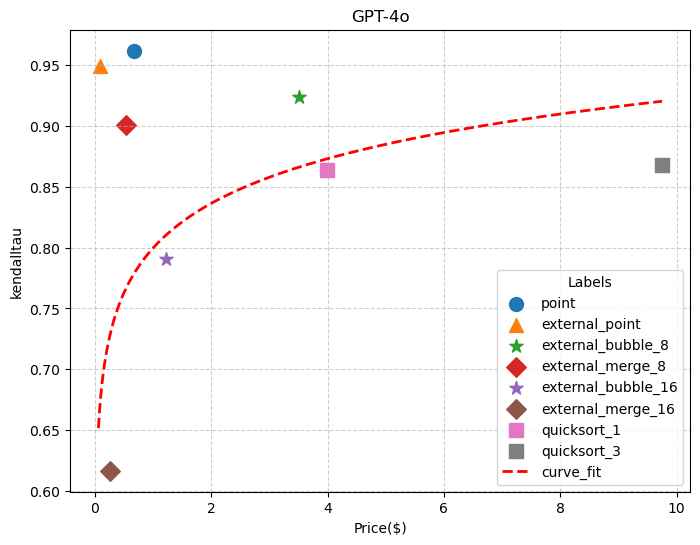

In [8]:
from scipy.optimize import curve_fit
# point kendalltau score: 0.9618090452261306, tokens: 73550, price: 0.665675.
# external pointwise, kendalltau score: 0.9490452261306532, tokens: 10052, price: 0.089645.

# quick_sort, kendalltau score: 0.8640201005025124, tokens: 473413, price: 3.994608.
# quicksort 3, kendalltau score: 0.8676381909547738, tokens: 1156025, price: 9.752165.

# external_bubble_sort 8, kendalltau score: 0.9261306532663316, tokens: 562754, price: 3.514288
# external_merge_sort 8, kendalltau score: 0.9006030150753769, tokens: 85154, price: 0.526707.

# external_bubble_sort 16, kendalltau score: 0.7909547738693467, tokens: 185998, price: 1.21408
# external_merge_sort 16, kendalltau score: 0.6165829145728643, tokens: 40675, price: 0.261258.


kendalltau = [0.9618090452261306,  0.9490452261306532, 
              0.9237185929648242, 0.9006030150753769,
              0.7909547738693467, 0.6165829145728643,
              0.8640201005025124,  0.8676381909547738
             ]
tokens = [73550, 10052,
          562754, 85154,
          185998,  40675,
          473413, 1156025
         ]

prices = [0.665675, 0.089645,
          3.514288, 0.526707,
          1.21408, 0.261258,
          3.994608, 9.752165
         ]

dot_labels = ["point", "external_point",\
              "external_bubble_8", "external_merge_8",\
              "external_bubble_16", "external_merge_16",\
              "quicksort_1", "quicksort_3"
             ]
markers = ['o', '^',\
           '*', 'D',
           '*', 'D',
           's', 's'
          ] 


# Create scatter plot
plt.figure(figsize=(8, 6))

for x, y, label, m in zip(prices, kendalltau, dot_labels, markers):
    plt.scatter(x, y, s=100, marker=m, label=label)



    
def log_linear(x, A, B, x0):
    return A * np.log(x + x0) + B

y_points = kendalltau[2:]
x_points = prices[2:]

x_points = np.array(x_points, dtype=float)
y_points = np.array(y_points, dtype=float)
# Initial guess and bounds (ensure x + x0 > 0 ⇒ x0 > -min(x); we keep x0 >= 1e-8)
p0 = [y_points.ptp(), y_points.min(), 0.1]
bounds = ([-np.inf, -np.inf, 1e-8], [np.inf, np.inf, np.inf])

popt, pcov = curve_fit(log_linear, x_points, y_points, p0=p0, bounds=bounds, maxfev=80000)
A, B, x0 = popt

# R^2
y_hat = log_linear(x_points, *popt)
ss_res = np.sum((y_points - y_hat)**2)
ss_tot = np.sum((y_points - y_points.mean())**2)
r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

# Smooth curve for plotting
x_fit = np.linspace(x_points.min()-0.2, x_points.max(), 1000)
y_fit = log_linear(x_fit, *popt)
plt.plot(x_fit, y_fit, 'r--', linewidth=2, label="curve_fit")

print("Fitted parameters:")
print(f"A = {A:.4f}")
print(f"B = {B:.4f}")
print(f"x0 = {x0:.4f}")

    

plt.legend(title="Labels")


# Axis labels and title
plt.xlabel("Price($)")
plt.ylabel("kendalltau")
plt.title("GPT-4o")

# Show grid and plot
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Fitted parameters:
A = 0.0394
B = 0.0611
x0 = 0.0000


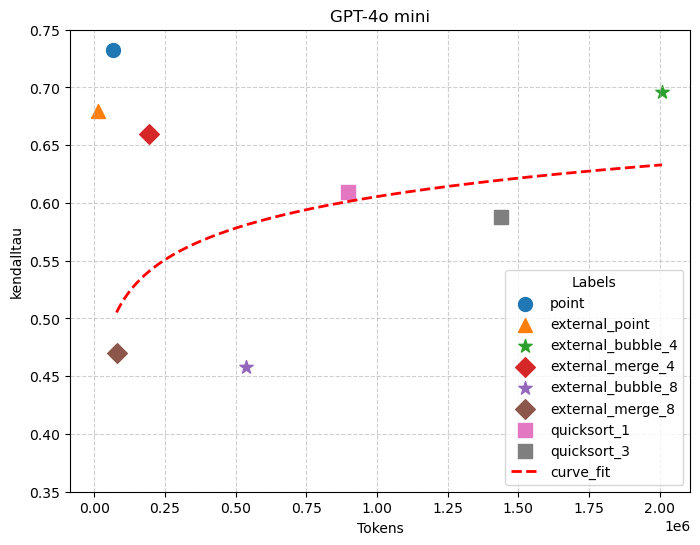

In [11]:
# pointwise_sort kendalltau score: 0.7321608040201005, tokens: 65391, price: 0.035045.
# external pointwise: m = 8 (agreement = 1.00), kendalltau score: 0.6793969849246231, tokens: 14502, price: 0.007692.


# quick_sort, kendalltau score: 0.6094472361809045, tokens: 898948, price: 0.436502.
# quick_sort 3, kendalltau score: 0.587537688442211, tokens: 1440085, price: 0.699603.

            
# external_bubble_sort 4, kendalltau score: 0.6961809045226129, tokens: 2008654, price: 0.756119
# external_merge_sort 4, kendalltau score: 0.6594974874371858, tokens: 191659, price: 0.070941

            
# external_bubble_sort 8, kendalltau score: 0.4578894472361809, tokens: 536900, price: 0.195285
# external_merge_sort 8, kendalltau score: 0.47035175879396984, tokens: 78433, price: 0.028626.

     
            

kendalltau = [0.7321608040201005, 0.6793969849246231,
              0.6961809045226129, 0.6594974874371858,
              0.4578894472361809, 0.47035175879396984,
              0.6094472361809045, 0.587537688442211
             ]
prices = [0.035045, 0.007692,
          0.756119, 0.070941,
          0.195285, 0.028626,
          0.436502, 0.699603,
         ]
tokens = [65391, 14502,
          2008654, 191659,
          536900, 78433,
          898948,1440085]

dot_labels = ["point", "external_point",\
              "external_bubble_4", "external_merge_4",
              "external_bubble_8", "external_merge_8",
              "quicksort_1", "quicksort_3",\
             ]
markers = ['o', '^',
           '*', 'D',
           "*", "D",
           's', 's'
          ] 

# Create scatter plot
plt.figure(figsize=(8, 6))

for x, y, label, m in zip(tokens, kendalltau, dot_labels, markers):
    plt.scatter(x, y, s=100, marker=m, label=label)
    
y_points = kendalltau[2:]
x_points = tokens[2:]

x_points = np.array(x_points, dtype=float)
y_points = np.array(y_points, dtype=float)
# Initial guess and bounds (ensure x + x0 > 0 ⇒ x0 > -min(x); we keep x0 >= 1e-8)
p0 = [y_points.ptp(), y_points.min(), 0.1]
bounds = ([-np.inf, -np.inf, 1e-8], [np.inf, np.inf, np.inf])

popt, pcov = curve_fit(log_linear, x_points, y_points, p0=p0, bounds=bounds, maxfev=80000)
A, B, x0 = popt

# R^2
y_hat = log_linear(x_points, *popt)
ss_res = np.sum((y_points - y_hat)**2)
ss_tot = np.sum((y_points - y_points.mean())**2)
r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

# Smooth curve for plotting
x_fit = np.linspace(x_points.min(), x_points.max(), 1000)
y_fit = log_linear(x_fit, *popt)
plt.plot(x_fit, y_fit, 'r--', linewidth=2, label="curve_fit")

print("Fitted parameters:")
print(f"A = {A:.4f}")
print(f"B = {B:.4f}")
print(f"x0 = {x0:.4f}")


plt.ylim(0.35, 0.75)
plt.legend(title="Labels")

# Axis labels and title
plt.xlabel("Tokens")
plt.ylabel("kendalltau")
plt.title("GPT-4o mini")

# Show grid and plot
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()